# JobFit CP2.4-CP2.6: Held-out evaluation figures and summary

This notebook turns the saved CP2.4 held-out report into the CP2.5 tables and figures, and checks the numbers used in the CP2.6 summary.

**Rules for this notebook**

- It only reads saved files. No API call, no model, no tuning.
- The configuration is frozen (D-087). Nothing here changes the model, prompt, K, metric, labels or rules.
- The headline is CV3-CV5 only. CV1-CV2 are a supplementary diagnostic and are never pooled with the headline.
- A missing label is never counted as 0 (D-052). Coverage is always written next to the number.

**Inputs**

- Report: `evals/results/cp24/heldout_report_v1.json` (contract `cp24-report-contract-v1`)
- Run files: `evals/results/cp24/test_run_v1/`
- Labels: `evals/gold/test_v13_cp24_r1/` (AI-assisted, human-reviewed, blind to ranking, D-088)

**Outputs**

- `reports/figures/cp2/fig09_cp24_heldout_primary_v1.png`, `fig10_cp24_supplementary_familiar_v1.png`, `fig11_cp24_order_decomposition_v1.png`
- `evals/results/cp24/cp25_tables_v1/` (CSV tables and a sha256 receipt)

Each section uses the pattern **Why, Result, What it means, Note, Next**.

## 0. Setup

In [1]:
import csv
import hashlib
import json
import os
import platform
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Run this notebook from the project root or the notebooks folder'
sys.path[:0] = [str(ROOT), str(ROOT / 'src')]

os.environ.setdefault('MPLCONFIGDIR', '/tmp/jobfit_mplconfig')
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jobfit.eval.heldout_report import PRIMARY, SUPPLEMENTARY, build_report, check_contract
from jobfit.eval.metrics import ranking_metrics

REPORT = ROOT / 'evals/results/cp24/heldout_report_v1.json'
RUN_DIR = ROOT / 'evals/results/cp24/test_run_v1'
GOLD = ROOT / 'evals/gold/test_v13_cp24_r1'
FIG = ROOT / 'reports/figures/cp2'
TABLES = ROOT / 'evals/results/cp24/cp25_tables_v1'
FIGS = {'primary': FIG / 'fig09_cp24_heldout_primary_v1.png',
        'supplementary': FIG / 'fig10_cp24_supplementary_familiar_v1.png',
        'decomposition': FIG / 'fig11_cp24_order_decomposition_v1.png'}

existing = [p for p in list(FIGS.values()) + [TABLES] if p.exists()]
assert not existing, f'Outputs already exist, bump the version instead of overwriting: {existing}'

PROVENANCE = 'Labels: AI-assisted (ChatGPT), human-reviewed (1 reviewer), blind to ranking; not independent human gold (D-088).'
BIAS = ('Labeling assistant and matcher are both OpenAI-family models: correlated preferences may inflate '
        'apparent agreement; direction and magnitude not measured.')
SIZE = 'Test: 3 synthetic held-out CVs (CV3-CV5), 68 pooled pairs over CV1-CV5, 67 judged + 1 unjudged (CV5/F00070).'
COLORS = {'stage1': '#7a8ca3', 'rule': '#c47a1d', 'final': '#1f5f99'}


def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def fmt(v):
    return 'n/a' if v is None else f'{v:.3f}'

print('Python', platform.python_version(), '| pandas', pd.__version__, '| matplotlib', matplotlib.__version__)

Matplotlib is building the font cache; this may take a moment.


Python 3.11.16 | pandas 2.3.3 | matplotlib 3.10.6


## 1. Load the inputs and reproduce the saved report

**Why:** the figures must show exactly the numbers of the frozen report. So first I rebuild the report from the labels with the frozen `build_report` and compare it with the saved file.

In [2]:
report = json.loads(REPORT.read_text())
run = json.loads((RUN_DIR / 'test_run.json').read_text())

labels = {}
for line in (GOLD / 'relevance_gold.jsonl').read_text().splitlines():
    row = json.loads(line)
    if row['review_status'] == 'approved':
        labels.setdefault(row['cv_id'], {})[row['job_id']] = int(row['relevance_0_3'])
held = json.loads((GOLD / 'held_test_r1.json').read_text())
provenance = json.loads((GOLD / 'provenance_manifest.json').read_text())
eligible = sorted((ROOT / 'evals/splits/test_job_ids.txt').read_text().split())

rebuilt = build_report(run, labels, eligible=eligible)
assert json.loads(json.dumps(rebuilt)) == report, 'Saved report does not reproduce from the labels'
check_contract(report)

judged = sum(len(v) for v in labels.values())
print('Report reproduced from labels: OK | contract:', report['contract'])
print('Label version:', provenance['label_version'], '| mode:', provenance['labeling_mode'])
print('Judged pairs:', judged, '| unjudged:', len(held), [(h['cv_id'], h['job_id']) for h in held])

Report reproduced from labels: OK | contract: cp24-report-contract-v1
Label version: test_v13_cp24_r1 | mode: ai_assisted_human_reviewed_blind_to_ranking
Judged pairs: 67 | unjudged: 1 [('CV5', 'F00070')]


**Result:** the saved report is rebuilt exactly from the labels, and the contract check passes.

**Note:** 68 pooled pairs, 67 judged and 1 unjudged (CV5/F00070, the JD has no assessable requirements). The unjudged pair is not counted as 0.

**Next:** build the tables with explicit coverage.

## 2. Tables with explicit coverage

**Why:** a macro number without its denominator can mislead. Every row says how many CVs are inside the number.

In [3]:
per = report['per_cv']
finals = {cv: json.loads((RUN_DIR / f'final_{cv}.json').read_text()) for cv in PRIMARY + SUPPLEMENTARY}
unjudged = {(h['cv_id'], h['job_id']) for h in held}

per_cv_rows = []
for cv in PRIMARY + SUPPLEMENTARY:
    f = finals[cv]
    statuses = [f['jobs'][j]['score']['status'] for j in f['order']]
    n_judged = len(labels.get(cv, {}))
    n_unjudged = sum(1 for c, _ in unjudged if c == cv)
    per_cv_rows.append({
        'cv_id': cv, 'group': per[cv]['group'],
        'pooled_pairs': n_judged + n_unjudged, 'judged_pairs': n_judged, 'unjudged_pairs': n_unjudged,
        'stage1_p_at_5': per[cv]['stage1']['p_at_5'], 'final_p_at_5': per[cv]['final']['p_at_5'],
        'stage1_ndcg_at_10': per[cv]['stage1']['ndcg_at_10'], 'final_ndcg_at_10': per[cv]['final']['ndcg_at_10'],
        'final_ndcg_reason': per[cv]['final']['ndcg_reason'] or '',
        'final_top10_unjudged': ' '.join(per[cv]['final']['unjudged_top10']),
        'final_top10_scored': sum(s in ('final', 'provisional') for s in statuses),
        'final_top10_held_or_no_score': sum(s not in ('final', 'provisional') for s in statuses),
    })

group_rows = []
for name in ('primary_heldout', 'supplementary_familiar'):
    g = report[name]
    for metric in ('p_at_5', 'ndcg_at_10'):
        m = g[metric]
        group_rows.append({
            'group': name, 'metric': metric, 'stage1_macro': m['stage1_macro'], 'final_macro': m['final_macro'],
            'cvs_included': m['cv_count'], 'cvs_planned': m['planned_cv_count'],
            'coverage': f"{m['cv_count']}/{m['planned_cv_count']} CV complete",
            'cvs_in_macro': ' '.join(cv for cv in g['cvs'] if cv not in m['omitted']),
            'omitted': '; '.join(f"{cv}: final {r['final']}" for cv, r in m['omitted'].items()),
        })

per_cv_df = pd.DataFrame(per_cv_rows)
group_df = pd.DataFrame(group_rows)
display(group_df.round(3))
display(per_cv_df.round(3))

,group,metric,stage1_macro,final_macro,cvs_included,cvs_planned,coverage,cvs_in_macro,omitted
0,primary_heldout,p_at_5,0.533,0.733,3,3,3/3 CV complete,CV3 CV4 CV5,
1,primary_heldout,ndcg_at_10,0.805,0.960,2,3,2/3 CV complete,CV3 CV4,CV5: final missing_original_position_judgment
2,supplementary_familiar,p_at_5,0.300,0.700,2,2,2/2 CV complete,CV1 CV2,
3,supplementary_familiar,ndcg_at_10,0.688,0.892,2,2,2/2 CV complete,CV1 CV2,


,cv_id,group,pooled_pairs,judged_pairs,unjudged_pairs,stage1_p_at_5,final_p_at_5,stage1_ndcg_at_10,final_ndcg_at_10,final_ndcg_reason,final_top10_unjudged,final_top10_scored,final_top10_held_or_no_score
0,CV3,primary_heldout,14,14,0,0.2,0.4,0.762,0.950,,,7,3
1,CV4,primary_heldout,12,12,0,0.8,1.0,0.847,0.970,,,9,1
2,CV5,primary_heldout,15,14,1,0.6,0.8,0.582,NaN,missing_original_position_judgment,F00070,5,5
3,CV1,supplementary_familiar,14,14,0,0.4,0.6,0.845,0.899,,,7,3
4,CV2,supplementary_familiar,13,13,0,0.2,0.8,0.530,0.884,,,8,2


**Result:** headline P@5 is 3/3 CV complete. Headline NDCG@10 is **2/3 CV complete**: the macro covers CV3 and CV4 only, because CV5 has the unjudged F00070 at final position 6. The stage-1 NDCG macro uses the same two CVs, so the pair stays comparable.

**What it means:** NDCG 0.960 is never a CV3-CV5 number.

**Next:** draw the headline figure.

## 3. Figure 9: held-out headline (CV3-CV5)

**Why:** show stage 1 against the final product order per CV, with the unavailable cell marked instead of drawn as 0.

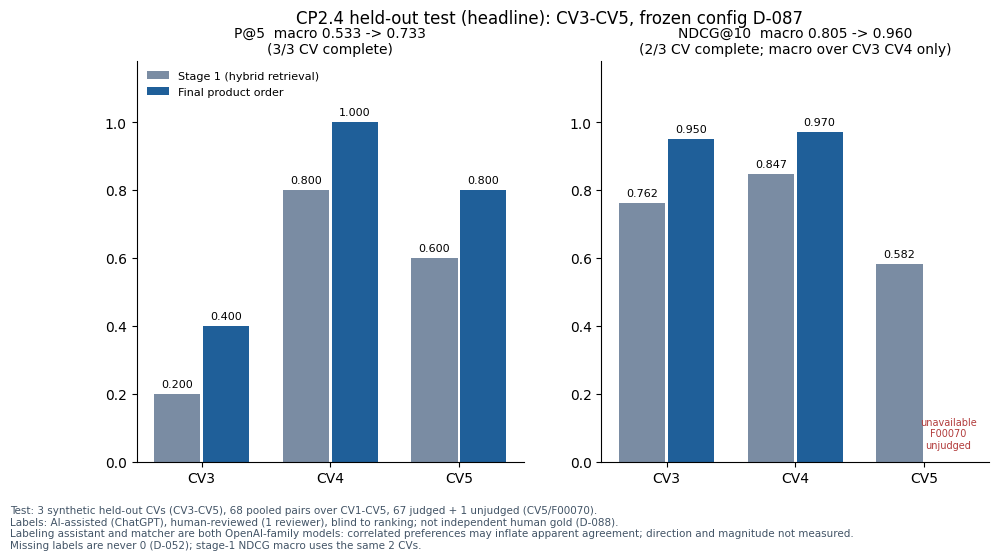

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, metric, title in ((axes[0], 'p_at_5', 'P@5'), (axes[1], 'ndcg_at_10', 'NDCG@10')):
    x = np.arange(len(PRIMARY))
    s = [per[cv]['stage1'][metric] for cv in PRIMARY]
    f = [per[cv]['final'][metric] for cv in PRIMARY]
    ax.bar(x - .19, s, .36, color=COLORS['stage1'], label='Stage 1 (hybrid retrieval)')
    ax.bar(x + .19, [v or 0 for v in f], .36, color=COLORS['final'], label='Final product order')
    for i, (a, b) in enumerate(zip(s, f)):
        ax.text(i - .19, a + .02, fmt(a), ha='center', fontsize=8)
        if b is None:
            ax.text(i + .19, .04, 'unavailable\nF00070\nunjudged', ha='center', fontsize=7, color='#b23b3b')
        else:
            ax.text(i + .19, b + .02, fmt(b), ha='center', fontsize=8)
    g = report['primary_heldout'][metric]
    only = ' '.join(cv for cv in PRIMARY if cv not in g['omitted'])
    ax.set_title(f"{title}  macro {fmt(g['stage1_macro'])} -> {fmt(g['final_macro'])}\n"
                 f"({g['cv_count']}/{g['planned_cv_count']} CV complete"
                 + (f'; macro over {only} only' if g['omitted'] else '') + ')', fontsize=10)
    ax.set_xticks(x, PRIMARY)
    ax.set_ylim(0, 1.18)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(loc='upper left', fontsize=8, frameon=False)
fig.suptitle('CP2.4 held-out test (headline): CV3-CV5, frozen config D-087', fontsize=12)
fig.text(.01, -.06, f'{SIZE}\n{PROVENANCE}\n{BIAS}\nMissing labels are never 0 (D-052); stage-1 NDCG macro uses the same 2 CVs.',
         fontsize=7.5, color='#425466', va='bottom')
FIG.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGS['primary'], dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

**Result:** P@5 macro 0.533 -> 0.733 (3/3 CV). NDCG@10 macro 0.805 -> 0.960 (2/3 CV, CV3-CV4).

**Note:** each P@5 step of 0.2 is one job in the top 5, and there are only three CVs. This is indicative, not a general result.

## 4. Figure 10: supplementary diagnostic (CV1-CV2)

**Why:** CV1-CV2 were used in development, so they are familiar profiles. They are shown in a separate figure and never pooled with the headline.

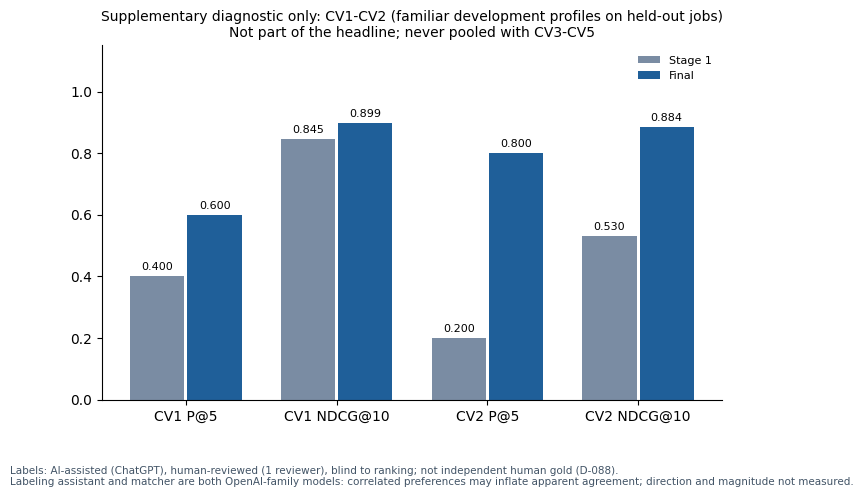

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.6))
names = [f'{cv} {m}' for cv in SUPPLEMENTARY for m in ('P@5', 'NDCG@10')]
s = [per[cv]['stage1'][m] for cv in SUPPLEMENTARY for m in ('p_at_5', 'ndcg_at_10')]
f = [per[cv]['final'][m] for cv in SUPPLEMENTARY for m in ('p_at_5', 'ndcg_at_10')]
x = np.arange(len(names))
ax.bar(x - .19, s, .36, color=COLORS['stage1'], label='Stage 1')
ax.bar(x + .19, f, .36, color=COLORS['final'], label='Final')
for i, (a, b) in enumerate(zip(s, f)):
    ax.text(i - .19, a + .02, fmt(a), ha='center', fontsize=8)
    ax.text(i + .19, b + .02, fmt(b), ha='center', fontsize=8)
ax.set_xticks(x, names)
ax.set_ylim(0, 1.15)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Supplementary diagnostic only: CV1-CV2 (familiar development profiles on held-out jobs)\n'
             'Not part of the headline; never pooled with CV3-CV5', fontsize=10)
fig.text(.01, -.08, f'{PROVENANCE}\n{BIAS}', fontsize=7.5, color='#425466', va='bottom')
fig.savefig(FIGS['supplementary'], dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Figure 11: where does the change come from? (post-hoc diagnostic)

**Why:** the final order has two parts: the deterministic seniority rule (before any LLM call) and the LLM match order. The analyzed top 10 in seniority-rule order (`analyzed_ids`) has the same jobs as the final top 10, so it can be scored with the same labels. This is only an explanation. It is not part of the frozen contract and it does not change anything.

,cv_id,group,stage1_p_at_5,seniority_pre_llm_p_at_5,final_p_at_5,stage1_ndcg_at_10,seniority_pre_llm_ndcg_at_10,final_ndcg_at_10,seniority_pre_llm_reason
0,CV3,primary_heldout,0.2,0.2,0.4,0.762,0.759,0.950,
1,CV4,primary_heldout,0.8,1.0,1.0,0.847,0.882,0.970,
2,CV5,primary_heldout,0.6,0.8,0.8,0.582,NaN,NaN,missing_original_position_judgment
3,CV1,supplementary_familiar,0.4,0.6,0.6,0.845,0.924,0.899,
4,CV2,supplementary_familiar,0.2,0.2,0.8,0.530,0.646,0.884,


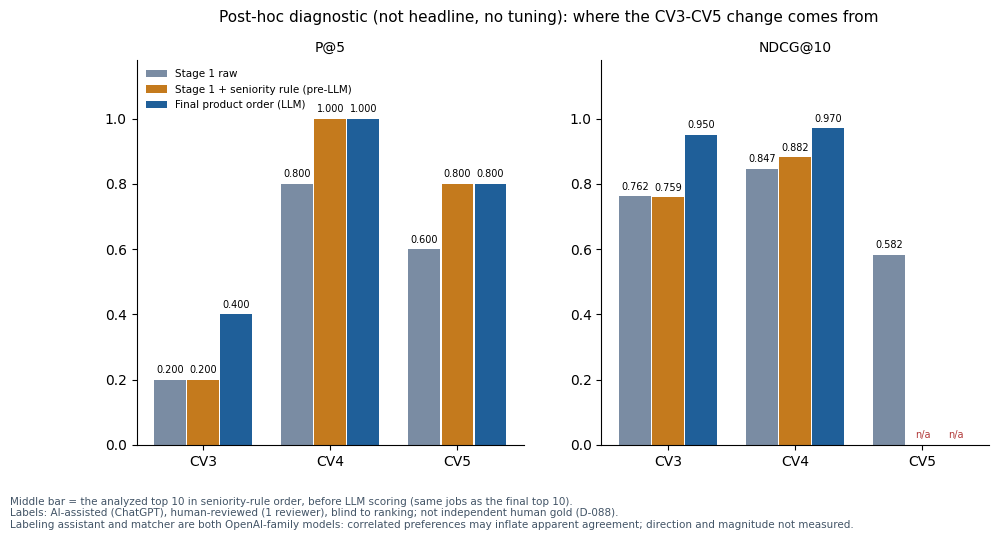

In [6]:
decomp_rows = []
for cv in PRIMARY + SUPPLEMENTARY:
    pre = finals[cv]['analyzed_ids']
    p5 = ranking_metrics(pre, labels[cv], eligible_ids=eligible, k=5)
    n10 = ranking_metrics(pre, labels[cv], eligible_ids=eligible, k=10)
    decomp_rows.append({
        'cv_id': cv, 'group': per[cv]['group'],
        'stage1_p_at_5': per[cv]['stage1']['p_at_5'],
        'seniority_pre_llm_p_at_5': p5['precision_at_k']['value'],
        'final_p_at_5': per[cv]['final']['p_at_5'],
        'stage1_ndcg_at_10': per[cv]['stage1']['ndcg_at_10'],
        'seniority_pre_llm_ndcg_at_10': n10['ndcg_at_k'],
        'final_ndcg_at_10': per[cv]['final']['ndcg_at_10'],
        'seniority_pre_llm_reason': n10['ndcg_reason'] or '',
    })
decomp_df = pd.DataFrame(decomp_rows)
display(decomp_df.round(3))

d = {r['cv_id']: r for r in decomp_rows}
series = [('stage1', COLORS['stage1'], 'Stage 1 raw'),
          ('seniority_pre_llm', COLORS['rule'], 'Stage 1 + seniority rule (pre-LLM)'),
          ('final', COLORS['final'], 'Final product order (LLM)')]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, metric, title in ((axes[0], 'p_at_5', 'P@5'), (axes[1], 'ndcg_at_10', 'NDCG@10')):
    x = np.arange(len(PRIMARY))
    for k, (key, color, name) in enumerate(series):
        vals = [d[cv][f'{key}_{metric}'] for cv in PRIMARY]
        ax.bar(x + (k - 1) * .26, [v or 0 for v in vals], .25, color=color, label=name)
        for i, v in enumerate(vals):
            ax.text(i + (k - 1) * .26, (v or 0) + .02, fmt(v), ha='center', fontsize=7,
                    color='#b23b3b' if v is None else 'black')
    ax.set_xticks(x, PRIMARY)
    ax.set_ylim(0, 1.18)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(loc='upper left', fontsize=7.5, frameon=False)
fig.suptitle('Post-hoc diagnostic (not headline, no tuning): where the CV3-CV5 change comes from', fontsize=11)
fig.text(.01, -.06, 'Middle bar = the analyzed top 10 in seniority-rule order, before LLM scoring (same jobs as the final top 10).\n'
         f'{PROVENANCE}\n{BIAS}', fontsize=7.5, color='#425466', va='bottom')
fig.savefig(FIGS['decomposition'], dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

**Result:** P@5 for CV4 (0.8 -> 1.0) and CV5 (0.6 -> 0.8) already reaches the final value with the seniority rule alone; only CV3 (0.2 -> 0.4) gains from the LLM order. For NDCG@10 the rule changes little (CV3 0.762 -> 0.759, CV4 0.847 -> 0.882), and the LLM order lifts CV3 to 0.950 and CV4 to 0.970.

**What it means:** the P@5 gain is mostly the rule; the NDCG gain is mostly the LLM order. The LLM-order part is where the OpenAI-family correlation risk applies most.

**Note:** in development (D-086) the LLM order gave no ranking gain. Both sets are very small, so neither result settles it.

## 6. Save tables and receipt

In [7]:
TABLES.mkdir(parents=True)
for name, df in (('per_cv.csv', per_cv_df), ('group_macros.csv', group_df), ('order_decomposition_posthoc.csv', decomp_df)):
    df.to_csv(TABLES / name, index=False)

inputs = [REPORT, RUN_DIR / 'test_run.json', GOLD / 'relevance_gold.jsonl', GOLD / 'held_test_r1.json',
          GOLD / 'provenance_manifest.json'] + [RUN_DIR / f'final_{cv}.json' for cv in PRIMARY + SUPPLEMENTARY]
outputs = list(FIGS.values()) + sorted(TABLES.iterdir())
receipt = {
    'notebook': 'notebooks/02_cp2_heldout_evaluation.ipynb', 'report_reproduced_from_labels': True,
    'contract': report['contract'], 'label_version': provenance['label_version'],
    'versions': {'python': platform.python_version(), 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__},
    'inputs_sha256': {str(p.relative_to(ROOT)): sha(p) for p in inputs},
    'outputs_sha256': {str(p.relative_to(ROOT)): sha(p) for p in outputs},
    'notes': ['Figure 11 and order_decomposition_posthoc.csv are post-hoc diagnostics, not part of the frozen '
              'contract and not used to change anything.'],
}
(TABLES / 'receipt.json').write_text(json.dumps(receipt, indent=1) + '\n')
print('Saved:', *[p.relative_to(ROOT) for p in outputs], TABLES.relative_to(ROOT) / 'receipt.json', sep='\n  ')

Saved:
  reports/figures/cp2/fig09_cp24_heldout_primary_v1.png
  reports/figures/cp2/fig10_cp24_supplementary_familiar_v1.png
  reports/figures/cp2/fig11_cp24_order_decomposition_v1.png
  evals/results/cp24/cp25_tables_v1/group_macros.csv
  evals/results/cp24/cp25_tables_v1/order_decomposition_posthoc.csv
  evals/results/cp24/cp25_tables_v1/per_cv.csv
  evals/results/cp24/cp25_tables_v1/receipt.json


## 7. CP2.6 summary

**Headline (CV3-CV5, held-out profiles and jobs):** P@5 0.533 -> 0.733 (3/3 CV complete). NDCG@10 0.805 -> 0.960 (**2/3 CV complete, CV3-CV4 only**; CV5 final NDCG unavailable, F00070 unjudged).

**Supplementary (CV1-CV2):** P@5 0.30 -> 0.70, NDCG@10 0.688 -> 0.892. Diagnostic only.

**What it supports:** the frozen product order was not worse than stage 1 on any complete headline cell. The P@5 gain is mostly the seniority rule; the NDCG gain is mostly the LLM order. The safe claim stays the D-086 one: the main value of stage 2 is the per-job evidence and gap explanation; a ranking gain is indicated on the test but not established.

**Limits:**

- 3 synthetic held-out CVs, 68 pooled pairs (67 judged + 1 unjudged), one job snapshot, one run per CV.
- Labels are AI-assisted (ChatGPT), human-reviewed by one reviewer, blind to ranking; not independent human gold (D-088).
- Because the labeling assistant and matcher are both OpenAI-family models, correlated model preferences may inflate apparent agreement. The direction and magnitude of this bias were not independently measured.
- Held or unscored jobs in the final top 10: CV3 3/10, CV4 1/10, CV5 5/10.

**Next:** ship the frozen configuration for CP3 without tuning. Future work (a new iteration): a second independent labeler or a non-OpenAI labeling assistant, more held-out CVs, and a lower held rate.